In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.activations import softmax, relu, linear
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from sklearn.model_selection import train_test_split

Importing Data from Kaggle

In [ ]:
import os

DATASET_NAME = "olafkrastovski/handwritten-digits-0-9"
SAVE_DIR = "/content/image"

os.makedirs(SAVE_DIR, exist_ok=True)

# Download and unzip dataset into /content/image
!kaggle datasets download -d {DATASET_NAME} -p {SAVE_DIR} --unzip

print("Dataset downloaded and saved to:", SAVE_DIR)

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
100% 66.7M/66.7M [00:00<00:00, 117MB/s]

Dataset downloaded and saved to: /content/image


Loading data into the program

In [ ]:
import os
import numpy as np
from PIL import Image

DATA_DIR = "/content/image"
IMG_SIZE = (28, 28)

X = []
y = []

class_names = sorted([
    folder for folder in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, folder))
])

print("Classes:", class_names)

for class_name in class_names:
    class_folder = os.path.join(DATA_DIR, class_name)

    for file_name in os.listdir(class_folder):
        file_path = os.path.join(class_folder, file_name)

        try:
            img = Image.open(file_path).convert("L")
            img = img.resize(IMG_SIZE)

            img_array = np.array(img)

            X.append(img_array)
            y.append(int(class_name))   # label comes from folder name

        except Exception as e:
            print("Skipped:", file_path, e)

X = np.array(X).astype("float32") / 255.0
y = np.array(y).astype("int32")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", np.unique(y, return_counts=True))

Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
X shape: (21555, 28, 28)
y shape: (21555,)
Labels: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=int32), array([2236, 2241, 2233, 2202, 2179, 2126, 2121, 2116, 2085, 2016]))


In [ ]:
idx = np.random.permutation(len(X)) #shuffling the data set
x = X[idx]
x = 1 - x #changing the background color
y = y[idx]

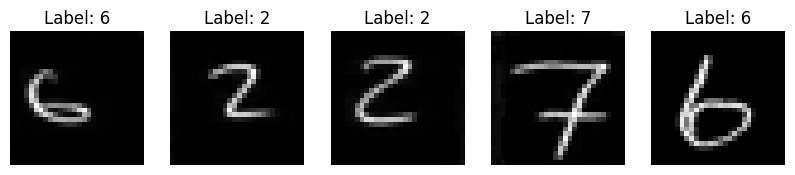

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y[i]}")
    plt.axis('off')
plt.show()

buidling different neural network to see which works best

In [ ]:
def load_model():

  model1 = Sequential ([
      Dense(units=25, activation=relu, name="l1"),
      Dense(units=15, activation=relu, name="l2"),
      Dense(units=10, activation=linear, name="o1")
  ])

  model2 = Sequential ([
      Dense(units=50, activation=relu, name="l1", kernel_regularizer=tf.keras.regularizers.l2(3e-3)),
      Dense(units=30, activation=relu, name="l2", kernel_regularizer=tf.keras.regularizers.l2(3e-3)),
      Dense(units=10, activation=linear, name="o1", kernel_regularizer = tf.keras.regularizers.l2(3e-3))
  ])

  model3 = Sequential ([
      Dense(units=75, activation=relu, name="l1", kernel_regularizer=tf.keras.regularizers.l2(2e-3)),
      Dense(units=45, activation=relu, name="l2", kernel_regularizer=tf.keras.regularizers.l2(2e-3)),
      Dense(units=10, activation=linear, name="o1", kernel_regularizer=tf.keras.regularizers.l2(2e-3))
  ])

  model4 = Sequential ([
      Dense(units=128, activation=relu, name="l1", kernel_regularizer=tf.keras.regularizers.l2(1e-3)),
      Dense(units=64, activation=relu, name="l2", kernel_regularizer=tf.keras.regularizers.l2(1e-3)),
      Dense(units=10, activation=linear, name="o1", kernel_regularizer=tf.keras.regularizers.l2(1e-3))
  ])


  return [model1, model2, model3, model4]

In [ ]:
x = x.reshape(x.shape[0], 28 * 28)

In [ ]:
x_train, x_, y_train, y_ = train_test_split(x,y,test_size=0.4, random_state=1)
x_test, x_cv, y_test, y_cv = train_test_split(x_, y_, test_size=0.5, random_state=2)

del x_, y_

print(f"train test> x_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"cross validation set/dev set> x_cv: {x_cv.shape}, y_cv: {y_cv.shape}")
print(f"test set> x_test: {x_test.shape}, y_test: {y_test.shape}")

train test> x_train: (12933, 784), y_train: (12933,)
cross validation set/dev set> x_cv: (4311, 784), y_cv: (4311,)
test set> x_test: (4311, 784), y_test: (4311,)


In [ ]:
models = load_model()

cv = []
train_error = []
trained_models = []

for model in models:

  model.compile(
      loss = SparseCategoricalCrossentropy(from_logits=True),
      optimizer = tf.keras.optimizers.Adam(0.001)
  )

  model.fit(x_train, y_train, epochs = 20, verbose=0)

  trained_models.append(model)

  yhat_pred = model.predict(x_train)
  train_prob = tf.nn.softmax(yhat_pred)
  train_predict = np.argmax(train_prob, axis=1)

  acc = np.mean(train_predict == y_train)
  train_error.append(acc)

  cv_yhat = model.predict(x_cv)
  cv_prob = tf.nn.softmax(cv_yhat)
  cv_predict = np.argmax(cv_prob, axis=1)

  cv_acc = np.mean(cv_predict == y_cv)
  cv.append(cv_acc)

  print(f"training acc: {acc}, cross validation acc: {cv_acc}")

405/405 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
training acc: 0.968143508853321, cross validation acc: 0.8703317095801438
